In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [126]:
df= pd.read_csv('../data/train.csv')

df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [127]:
df.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

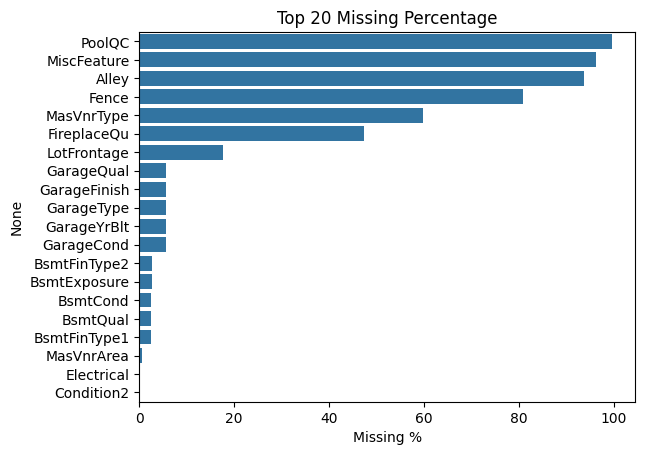

In [128]:
missing_pct = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)

sns.barplot(
    x=missing_pct.head(20).values,
    y=missing_pct.head(20).index
)
plt.xlabel("Missing %")
plt.title("Top 20 Missing Percentage")
plt.show()

In [129]:
df.isnull().sum().sort_values(ascending=False).head(4)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
dtype: int64

In [130]:
drop_cols = [
    'PoolQC', 'MiscFeature','Alley','Fence'   
]

df = df.drop(drop_cols, axis=1)

In [131]:
df.isnull().sum().sort_values(ascending=False).head(4)

MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageFinish     81
dtype: int64

In [132]:
df['MasVnrType'].head(20)

0     BrkFace
1         NaN
2     BrkFace
3         NaN
4     BrkFace
5         NaN
6       Stone
7       Stone
8         NaN
9         NaN
10        NaN
11      Stone
12        NaN
13      Stone
14    BrkFace
15        NaN
16    BrkFace
17        NaN
18        NaN
19        NaN
Name: MasVnrType, dtype: str

In [133]:
df['MasVnrType'] = df['MasVnrType'].fillna("No_MasVnr")

In [134]:
df.isnull().sum().sort_values(ascending=False).head(4)

FireplaceQu     690
LotFrontage     259
GarageFinish     81
GarageYrBlt      81
dtype: int64

In [135]:
df['FireplaceQu'] = df['FireplaceQu'].fillna("N0_firePlace")

In [136]:
df['LotFrontage'].head(20)

0     65.0
1     80.0
2     68.0
3     60.0
4     84.0
5     85.0
6     75.0
7      NaN
8     51.0
9     50.0
10    70.0
11    85.0
12     NaN
13    91.0
14     NaN
15    51.0
16     NaN
17    72.0
18    66.0
19    70.0
Name: LotFrontage, dtype: float64

In [137]:
df['LotFrontage_missing'] = df['LotFrontage'].isnull().astype(int)

In [138]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

In [139]:
df.isnull().sum().sort_values(ascending=False).head(6)

GarageType      81
GarageYrBlt     81
GarageCond      81
GarageFinish    81
GarageQual      81
BsmtFinType2    38
dtype: int64

In [140]:
garage_cols = ['GarageType','GarageCond','GarageFinish', 'GarageQual']

In [141]:
for col in garage_cols:
    df[col] = df[col].fillna("No_garage")

In [142]:
df.isnull().sum().sort_values(ascending=False).head(6)

GarageYrBlt     81
BsmtFinType2    38
BsmtExposure    38
BsmtQual        37
BsmtFinType1    37
BsmtCond        37
dtype: int64

In [143]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['GarageYrBlt'].median())

In [144]:
df.isnull().sum().sort_values(ascending=False).head(6)

BsmtExposure    38
BsmtFinType2    38
BsmtFinType1    37
BsmtQual        37
BsmtCond        37
MasVnrArea       8
dtype: int64

In [145]:
col_bsmt = [
    'BsmtExposure','BsmtFinType2','BsmtFinType1','BsmtQual','BsmtCond'
]

In [146]:
for col in col_bsmt:
    df[col] = df[col].fillna('No_Bsmt')

In [147]:
df.isnull().sum().sort_values(ascending=False).head(6)

MasVnrArea     8
Electrical     1
MSZoning       0
LotFrontage    0
Id             0
MSSubClass     0
dtype: int64

In [148]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(df['MasVnrArea'].median()) 

In [149]:
df.isnull().sum().sort_values(ascending=False).head(6)

Electrical     1
Id             0
MSZoning       0
LotFrontage    0
LotArea        0
MSSubClass     0
dtype: int64

In [150]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [151]:
df.isnull().sum().sort_values(ascending=False)


Id                     0
MSSubClass             0
MSZoning               0
LotFrontage            0
LotArea                0
                      ..
YrSold                 0
SaleType               0
SaleCondition          0
SalePrice              0
LotFrontage_missing    0
Length: 78, dtype: int64

Now we do not have any null values. we will check for any duplicate values


In [152]:
df.duplicated().sum()

np.int64(0)

No Duplilcate values as  well.


In [153]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 78 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   1460 non-null   int64  
 1   MSSubClass           1460 non-null   int64  
 2   MSZoning             1460 non-null   str    
 3   LotFrontage          1460 non-null   float64
 4   LotArea              1460 non-null   int64  
 5   Street               1460 non-null   str    
 6   LotShape             1460 non-null   str    
 7   LandContour          1460 non-null   str    
 8   Utilities            1460 non-null   str    
 9   LotConfig            1460 non-null   str    
 10  LandSlope            1460 non-null   str    
 11  Neighborhood         1460 non-null   str    
 12  Condition1           1460 non-null   str    
 13  Condition2           1460 non-null   str    
 14  BldgType             1460 non-null   str    
 15  HouseStyle           1460 non-null   str    
 16 

All Dytpes are also correct

In [154]:
df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontage_missing
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,2,2008,WD,Normal,208500,0
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,5,2007,WD,Normal,181500,0
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,9,2008,WD,Normal,223500,0


<Axes: xlabel='SalePrice', ylabel='Count'>

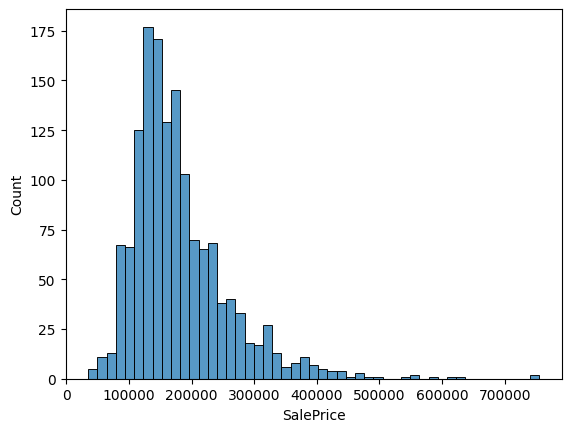

In [155]:
sns.histplot(df['SalePrice'])

now before making the Train and testing sets we need to normalize the value for the SalePrice as it is in very high number so we are going to use the transformation featuring for it.

In [156]:
df['Log_SalePrice'] = np.log1p(df['SalePrice'])

<Axes: xlabel='Log_SalePrice', ylabel='Count'>

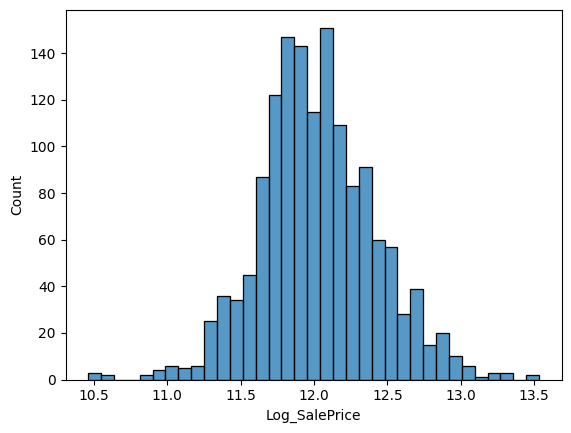

In [157]:
sns.histplot(df['Log_SalePrice'])

this is dataset is fulling cleaned and featured

In [163]:
print('Shape of tables: ', df.shape)
print('Null Values: ',df.isnull().sum().sum())
print('Duplicated Values: ',df.duplicated().sum())

Shape of tables:  (1460, 79)
Null Values:  0
Duplicated Values:  0


In [164]:
df.to_csv('../data/Cleaned_train.csv', index=False)